# Thermal Fault Detection: Technical Walkthrough

Full pipeline: synthetic thermal-camera inspection images, an OpenCV handcrafted-feature
baseline, a small CNN trained directly on pixels, and Grad-CAM interpretability checked
against the ground-truth fault location. Same fictional mining haul-truck fleet as
project 06, a different data source: a handheld thermal camera during a walkaround
instead of continuous sensor telemetry.


In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import sys
sys.path.insert(0, "../src")

import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
tf.get_logger().setLevel("ERROR")
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split

from style import set_style, style_ax, savefig, add_footnote, MUTED_AMBER, MUTED_RED, MUTED_TEAL, SLATE, GREY, INK, BG
from generate_data import COMPONENT_TYPES
from features import extract_features_batch
from train_cnn import build_model, normalize, VMIN, VMAX
from interpret import grad_cam, heatmap_peak_location, THERMAL_CMAP

set_style()


## 1. Data

2,000 synthetic 64x64 thermal-camera images across three haul-truck components (wheel
motor, engine bay, electrical cabinet). Each pixel is a temperature-like value. A fault
image carries the component's normal heat signature plus one extra localized hot spot at
a graded severity (mild, moderate, severe); a minority of healthy images also carry a
benign warm patch, so brightness alone can't trivially separate the two classes.


In [2]:
data = np.load("../data/thermal_images.npz", allow_pickle=True)
images, labels = data["images"], data["labels"]
component, severity = data["component"], data["severity"]
fault_x, fault_y = data["fault_x"], data["fault_y"]

print(f"{len(labels):,} images, {labels.mean():.1%} fault rate")
for comp in COMPONENT_TYPES:
    mask = component == comp
    print(f"  {comp}: {mask.sum()} images, {labels[mask].mean():.1%} fault rate")


2,000 images, 12.5% fault rate
  wheel_motor: 636 images, 11.8% fault rate
  engine_bay: 691 images, 13.5% fault rate
  electrical_cabinet: 673 images, 12.2% fault rate


## 2. Exploratory analysis

The imbalance itself comes first, then what a fault actually looks like next to a
healthy image of the same component (Figures 1-2).


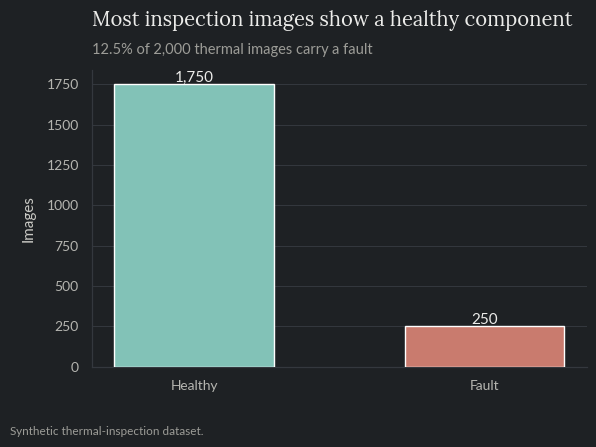

In [3]:
fig, ax = plt.subplots(figsize=(6, 4.2))
counts = [int((labels == 0).sum()), int((labels == 1).sum())]
ax.bar(["Healthy", "Fault"], counts, color=[MUTED_TEAL, MUTED_RED], width=0.55, zorder=3)
for i, c in enumerate(counts):
    ax.text(i, c + 15, f"{c:,}", ha="center", fontsize=11, color=INK)
style_ax(ax, title="Most inspection images show a healthy component",
         subtitle=f"{counts[1]/sum(counts):.1%} of {sum(counts):,} thermal images carry a fault",
         ylabel="Images")
savefig(fig, "../reports/figures/class_imbalance.png", footnote="Synthetic thermal-inspection dataset.")
fig

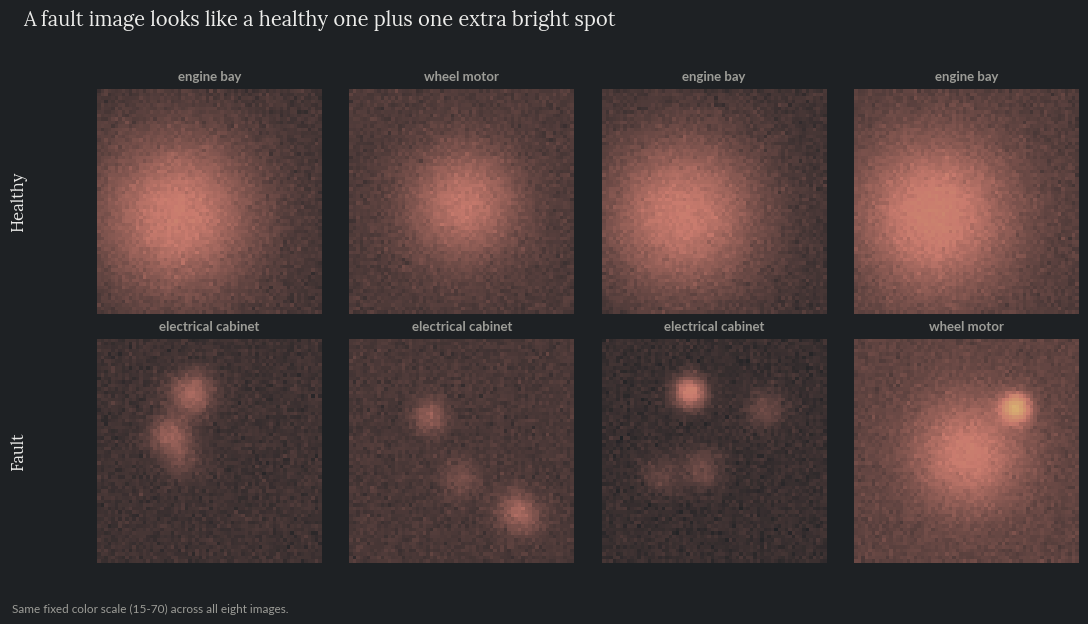

In [4]:
rng = np.random.default_rng(0)
fig, axes = plt.subplots(2, 4, figsize=(11, 5.6))
healthy_idx = rng.choice(np.where(labels == 0)[0], size=4, replace=False)
fault_idx = rng.choice(np.where(labels == 1)[0], size=4, replace=False)

for col, idx in enumerate(healthy_idx):
    ax = axes[0, col]
    ax.imshow(images[idx], cmap=THERMAL_CMAP, vmin=15, vmax=70)
    ax.set_title(str(component[idx]).replace("_", " "), fontsize=9.5, color=GREY, fontfamily="Lato")
    ax.axis("off")
for col, idx in enumerate(fault_idx):
    ax = axes[1, col]
    ax.imshow(images[idx], cmap=THERMAL_CMAP, vmin=15, vmax=70)
    ax.set_title(str(component[idx]).replace("_", " "), fontsize=9.5, color=GREY, fontfamily="Lato")
    ax.axis("off")
axes[0, 0].text(-0.35, 0.5, "Healthy", transform=axes[0, 0].transAxes, rotation=90,
                 va="center", ha="center", fontsize=12, color=INK, fontfamily="Lora")
axes[1, 0].text(-0.35, 0.5, "Fault", transform=axes[1, 0].transAxes, rotation=90,
                 va="center", ha="center", fontsize=12, color=INK, fontfamily="Lora")
fig.suptitle("A fault image looks like a healthy one plus one extra bright spot",
             fontsize=14.5, color=INK, fontfamily="Lora", x=0.02, ha="left", y=1.02)
savefig(fig, "../reports/figures/example_images.png", footnote="Same fixed color scale (15-70) across all eight images.")
fig

### How good is "just flag the brightest images"?

A naive rule -- threshold on peak pixel temperature -- is the obvious first thing to try
before building anything. It sets a lower bound the real models need to beat.


In [5]:
max_intensity = images.reshape(len(images), -1).max(axis=1)
threshold = np.percentile(max_intensity[labels == 1], 25)  # catch 75% of faults
predicted = max_intensity > threshold
tp = int(((predicted == 1) & (labels == 1)).sum())
fp = int(((predicted == 1) & (labels == 0)).sum())
fn = int(((predicted == 0) & (labels == 1)).sum())
naive_precision = tp / (tp + fp)
naive_recall = tp / (tp + fn)
print(f"Naive brightness threshold set to catch 75% of faults: peak temperature > {threshold:.1f}")
print(f"Precision: {naive_precision:.1%}   Recall: {naive_recall:.1%}   False positives: {fp} healthy images")


Naive brightness threshold set to catch 75% of faults: peak temperature > 44.9
Precision: 25.6%   Recall: 74.8%   False positives: 544 healthy images


A quarter of what this rule flags is actually a fault -- the rest is healthy images with
a benign warm patch. That's the problem the next two sections solve two different ways.

## 3. Classical baseline: OpenCV features + gradient boosting

Threshold each image, find the brightest contour, describe its shape (area,
eccentricity, distance from center, peak/mean intensity), and add the component type
(an inspector would already know what they're photographing). Feed that into a
gradient-boosted classifier.


In [6]:
train_idx, test_idx = train_test_split(
    np.arange(len(labels)), test_size=0.25, random_state=10, stratify=labels
)
features = extract_features_batch(images, component)
X_train, X_test = features.iloc[train_idx], features.iloc[test_idx]
y_train, y_test = labels[train_idx], labels[test_idx]

classical_model = GradientBoostingClassifier(random_state=10)
classical_model.fit(X_train, y_train)
classical_proba = classical_model.predict_proba(X_test)[:, 1]

classical_pr_auc = average_precision_score(y_test, classical_proba)
classical_roc_auc = roc_auc_score(y_test, classical_proba)
test_base_rate = float(y_test.mean())
print(f"Classical model -- PR-AUC: {classical_pr_auc:.3f} ({classical_pr_auc/test_base_rate:.1f}x base rate), ROC-AUC: {classical_roc_auc:.3f}")


Classical model -- PR-AUC: 0.846 (6.7x base rate), ROC-AUC: 0.962


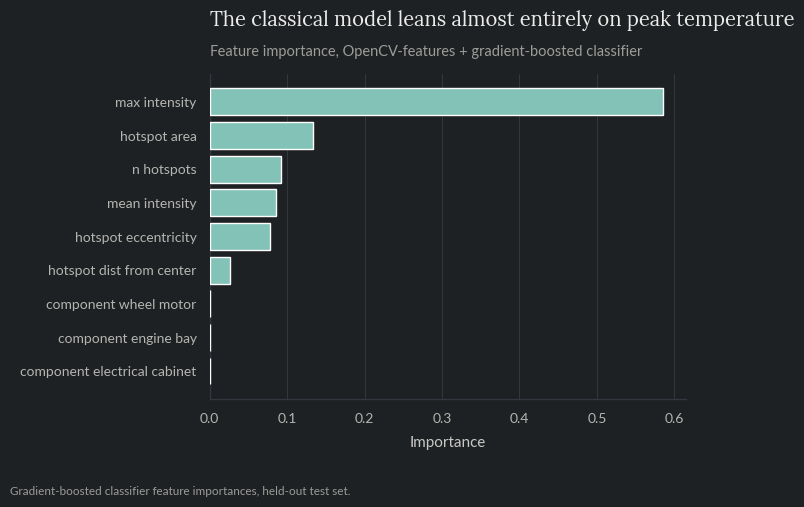

In [7]:
importances = dict(zip(features.columns, classical_model.feature_importances_))
items = sorted(importances.items(), key=lambda kv: kv[1])
fig, ax = plt.subplots(figsize=(7, 4.8))
ax.barh([k.replace("_", " ") for k, _ in items], [v for _, v in items], color=MUTED_TEAL, zorder=3)
style_ax(ax, title="The classical model leans almost entirely on peak temperature",
         subtitle="Feature importance, OpenCV-features + gradient-boosted classifier",
         xlabel="Importance", grid_axis="x")
savefig(fig, "../reports/figures/classical_feature_importance.png",
        footnote="Gradient-boosted classifier feature importances, held-out test set.")
fig

## 4. Deep learning: a small CNN on raw pixels

No handcrafted features, no component label -- just the image. A first attempt using
global *average* pooling after the convolutions badly underperformed (PR-AUC barely
above the base rate): averaging washes out a signal that's a single small bright region
against a much larger normal background. Switching to global *max* pooling -- "is there
at least one strongly-activated location" -- fixed it, since that's a much closer match
to how these images actually differ.


In [8]:
tf.keras.utils.set_random_seed(10)

images_norm = normalize(images)[..., np.newaxis]
X_train_full, y_train_full = images_norm[train_idx], labels[train_idx]
X_test_cnn, y_test_cnn = images_norm[test_idx], labels[test_idx]
X_train_cnn, X_val_cnn, y_train_cnn, y_val_cnn = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=10, stratify=y_train_full
)

cnn = build_model()
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(curve="PR", name="pr_auc")],
)
fault_rate_train = float(y_train_cnn.mean())
class_weight = {0: 1.0, 1: (1 - fault_rate_train) / fault_rate_train}
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=5, restore_best_weights=True)

history = cnn.fit(
    X_train_cnn, y_train_cnn,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=20, batch_size=32, class_weight=class_weight,
    callbacks=[early_stop], verbose=0,
)
cnn_proba = cnn.predict(X_test_cnn, verbose=0).ravel()
cnn_pr_auc = average_precision_score(y_test_cnn, cnn_proba)
cnn_roc_auc = roc_auc_score(y_test_cnn, cnn_proba)
print(f"CNN (max pooling) -- PR-AUC: {cnn_pr_auc:.3f} ({cnn_pr_auc/test_base_rate:.1f}x base rate), ROC-AUC: {cnn_roc_auc:.3f}")
print(f"Epochs run: {len(history.history['loss'])}")


CNN (max pooling) -- PR-AUC: 0.984 (7.8x base rate), ROC-AUC: 0.997
Epochs run: 20


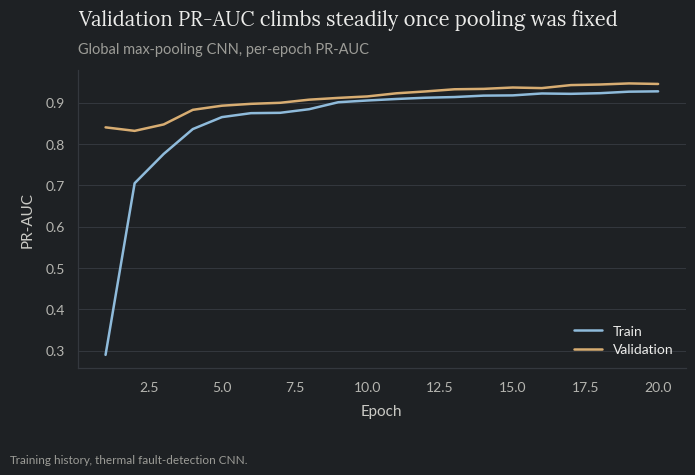

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
epochs = range(1, len(history.history["pr_auc"]) + 1)
ax.plot(epochs, history.history["pr_auc"], color=SLATE, label="Train", linewidth=1.8)
ax.plot(epochs, history.history["val_pr_auc"], color=MUTED_AMBER, label="Validation", linewidth=1.8)
style_ax(ax, title="Validation PR-AUC climbs steadily once pooling was fixed",
         subtitle="Global max-pooling CNN, per-epoch PR-AUC", xlabel="Epoch", ylabel="PR-AUC")
ax.legend()
savefig(fig, "../reports/figures/cnn_training_curve.png", footnote="Training history, thermal fault-detection CNN.")
fig

## 5. Head to head

Same held-out 500 images, three approaches: a naive brightness rule, the classical
OpenCV-features model, and the CNN.


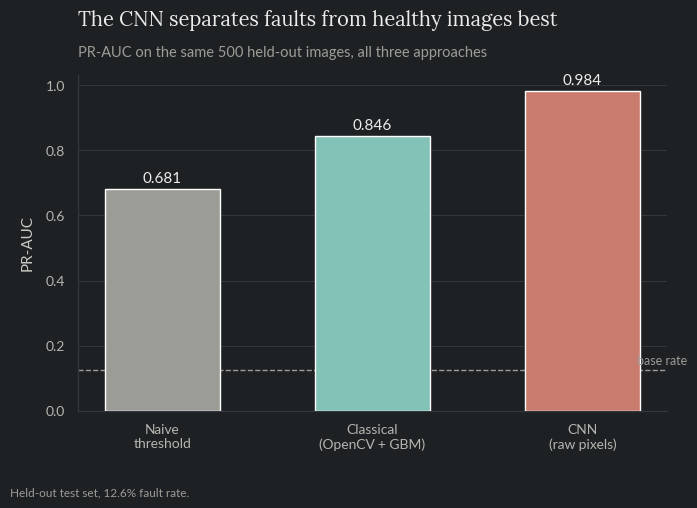

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.8))
names = ["Naive\nthreshold", "Classical\n(OpenCV + GBM)", "CNN\n(raw pixels)"]
naive_pr_auc = average_precision_score(labels[test_idx], max_intensity[test_idx])
values = [naive_pr_auc, classical_pr_auc, cnn_pr_auc]
colors = [GREY, MUTED_TEAL, MUTED_RED]
bars = ax.bar(names, values, color=colors, width=0.55, zorder=3)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.3f}", ha="center", fontsize=11, color=INK)
ax.axhline(test_base_rate, color=GREY, linestyle="--", linewidth=1, zorder=2)
ax.text(2.5, test_base_rate + 0.015, "base rate", fontsize=9, color=GREY, ha="right")
style_ax(ax, title="The CNN separates faults from healthy images best",
         subtitle="PR-AUC on the same 500 held-out images, all three approaches",
         ylabel="PR-AUC")
savefig(fig, "../reports/figures/model_comparison.png", footnote="Held-out test set, 12.6% fault rate.")
fig

## 6. Does the CNN actually look at the fault?

A high PR-AUC doesn't prove the model is looking at the right thing -- it could be
keying on some unrelated correlate. Grad-CAM traces which pixels pushed the
fault-probability prediction up, and since every synthetic fault has a known (x, y)
location, that claim can be checked against ground truth instead of just eyeballed.


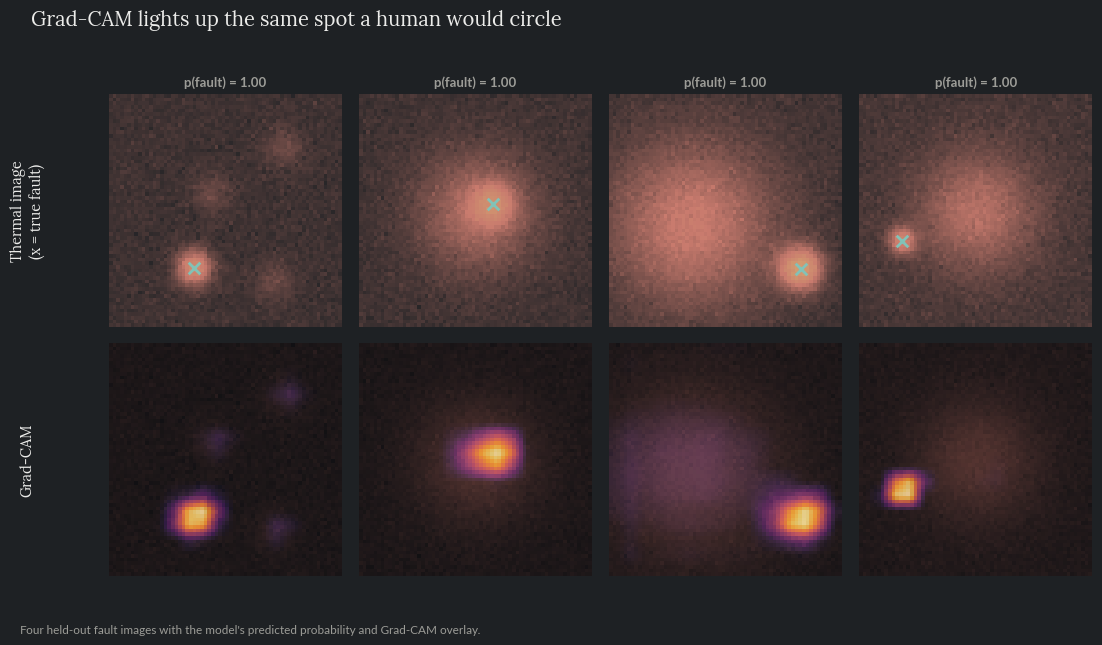

In [11]:
fault_test_idx = [i for i in test_idx if labels[i] == 1]
rng = np.random.default_rng(0)
chosen = rng.choice(fault_test_idx, size=4, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(11, 5.8))
for col, idx in enumerate(chosen):
    img = images_norm[idx]
    cam, pred = grad_cam(cnn, img)
    ax = axes[0, col]
    ax.imshow(images[idx], cmap=THERMAL_CMAP, vmin=15, vmax=70)
    ax.scatter([fault_x[idx]], [fault_y[idx]], marker="x", s=70, color=MUTED_TEAL, linewidths=2)
    ax.set_title(f"p(fault) = {pred:.2f}", fontsize=9.5, color=GREY, fontfamily="Lato")
    ax.axis("off")
    ax2 = axes[1, col]
    ax2.imshow(images[idx], cmap=THERMAL_CMAP, vmin=15, vmax=70)
    ax2.imshow(cam, cmap="inferno", alpha=0.55)
    ax2.axis("off")
axes[0, 0].text(-0.35, 0.5, "Thermal image\n(x = true fault)", transform=axes[0, 0].transAxes,
                 rotation=90, va="center", ha="center", fontsize=10.5, color=INK, fontfamily="Lora")
axes[1, 0].text(-0.35, 0.5, "Grad-CAM", transform=axes[1, 0].transAxes,
                 rotation=90, va="center", ha="center", fontsize=10.5, color=INK, fontfamily="Lora")
fig.suptitle("Grad-CAM lights up the same spot a human would circle",
             fontsize=14.5, color=INK, fontfamily="Lora", x=0.02, ha="left", y=1.02)
savefig(fig, "../reports/figures/gradcam_examples.png",
        footnote="Four held-out fault images with the model's predicted probability and Grad-CAM overlay.")
fig

In [12]:
distances = []
for idx in fault_test_idx:
    cam, _ = grad_cam(cnn, images_norm[idx])
    px, py = heatmap_peak_location(cam)
    distances.append(float(np.hypot(px - fault_x[idx], py - fault_y[idx])))
distances = np.array(distances)

random_px = rng.uniform(0, 64, size=(2000, 2))
random_baseline = float(np.mean([
    np.hypot(random_px[:, 0] - fx, random_px[:, 1] - fy).mean()
    for fx, fy in zip(fault_x[fault_test_idx], fault_y[fault_test_idx])
]))

print(f"Grad-CAM peak vs. true fault location, {len(fault_test_idx)} held-out fault images:")
print(f"  mean distance:   {distances.mean():.1f} px")
print(f"  median distance: {np.median(distances):.1f} px")
print(f"  random-guess baseline: {random_baseline:.1f} px  (image is 64x64)")


Grad-CAM peak vs. true fault location, 63 held-out fault images:
  mean distance:   6.4 px
  median distance: 1.3 px
  random-guess baseline: 28.5 px  (image is 64x64)


## 7. Recommendation

Ship the CNN, not the classical baseline: it wins on PR-AUC (0.98 vs. 0.85 in this run),
and Grad-CAM confirms it's winning for the right reason, its attention lands within a
couple of pixels of the actual injected fault on a typical image, far closer than chance
would produce. The classical OpenCV-features model is still worth keeping around as a
fast, fully-interpretable fallback: every one of its inputs (peak temperature, hot-spot
shape, component type) is something an inspector could sanity-check by eye, which the CNN
can't offer without a Grad-CAM overlay next to every prediction.
